In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load outlet features
features_df = pd.read_parquet('../../data/Intermediate/outlet_features.parquet')
print(f"Total outlets in features: {len(features_df)}")


Total outlets in features: 116183


In [3]:
# Separate Churn Outlets
# Based on M5, outlets with is_active == False are churned
churn_outlets = features_df[features_df['is_active'] == False].copy()
active_outlets = features_df[features_df['is_active'] == True].copy()

print(f"Churn outlets count: {len(churn_outlets)}")
print(f"Active outlets count: {len(active_outlets)}")


Churn outlets count: 49447
Active outlets count: 66736


In [4]:
# Separate Power Outlets
# Using 3x IQR rule on total_net_sales
Q1 = active_outlets['total_net_sales'].quantile(0.25)
Q3 = active_outlets['total_net_sales'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

power_outlets = active_outlets[active_outlets['total_net_sales'] > upper_bound].copy()
mainstream_outlets = active_outlets[active_outlets['total_net_sales'] <= upper_bound].copy()

print(f"Power outlets count: {len(power_outlets)}")
print(f"Power outlets revenue share: {power_outlets['total_net_sales'].sum() / active_outlets['total_net_sales'].sum() * 100:.2f}%")
print(f"Mainstream outlets count for clustering: {len(mainstream_outlets)}")


Power outlets count: 5374
Power outlets revenue share: 75.55%
Mainstream outlets count for clustering: 61362


In [5]:
# Feature Preprocessing
# Select features based on M5 synthesis
features = [
    'avg_txn_per_active_month', 
    'avg_net_sales_per_txn', 
    'avg_qty_per_txn', 
    'n_unique_categories', 
    'return_rate', 
    'momentum', 
    'pct_cash_txn'
]
# recency_months is excluded due to zero variance among active outlets

X = mainstream_outlets[features].copy()

# Log transform skewed features
X['avg_net_sales_per_txn_log'] = np.log1p(X['avg_net_sales_per_txn'])
X['avg_qty_per_txn_log'] = np.log1p(X['avg_qty_per_txn'])
X = X.drop(columns=['avg_net_sales_per_txn', 'avg_qty_per_txn'])

# Winsorize momentum (1st and 99th percentiles)
p1 = X['momentum'].quantile(0.01)
p99 = X['momentum'].quantile(0.99)
X['momentum_winsor'] = X['momentum'].clip(lower=p1, upper=p99)
X = X.drop(columns=['momentum'])

# Standard Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Scaled Features Shape:", X_scaled_df.shape)


Scaled Features Shape: (61362, 7)


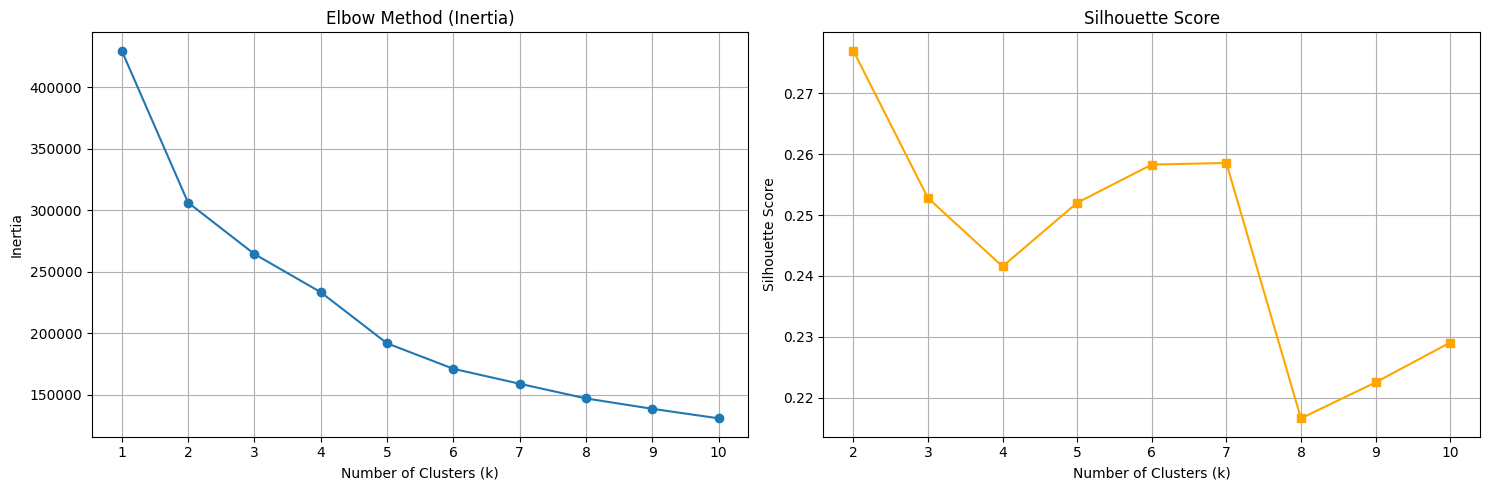

In [6]:
# Run K-Means for k=1 to 10 and collect metrics
inertias = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score is only defined for k > 1
    if k > 1:
        # Taking a sample to compute silhouette faster if dataset is large
        if len(X_scaled_df) > 10000:
            sample_idx = np.random.choice(X_scaled_df.index, size=10000, replace=False)
            labels = kmeans.predict(X_scaled_df.loc[sample_idx])
            score = silhouette_score(X_scaled_df.loc[sample_idx], labels)
        else:
            score = silhouette_score(X_scaled_df, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
ax1.plot(k_range, inertias, marker='o')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)
ax1.grid(True)

# Silhouette Plot
ax2.plot(k_range[1:], silhouette_scores[1:], marker='s', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range[1:])
ax2.grid(True)

plt.tight_layout()
plt.show()


In [7]:
# --- WAITING FOR USER INPUT ---
# Please look at the elbow and silhouette plots above and determine the optimal k.
# Set optimal_k below to your selected value.


In [8]:
optimal_k = 2 # <--- Replace with selected k

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
mainstream_outlets['cluster'] = kmeans_final.fit_predict(X_scaled_df)
print(f"Clustered {len(mainstream_outlets)} mainstream outlets into {optimal_k} clusters.")


Clustered 61362 mainstream outlets into 2 clusters.


In [9]:
# Get cluster means for the original unscaled features used for clustering
mainstream_outlets.groupby('cluster')[features].mean()


,avg_txn_per_active_month,avg_net_sales_per_txn,avg_qty_per_txn,n_unique_categories,return_rate,momentum,pct_cash_txn
cluster,,,,,,,
0,4.137876,5053.473766,127.965913,3.998377,0.260751,0.462313,0.419640
1,1.810780,1264.571708,34.339746,1.929140,0.054544,0.484533,0.264795


In [10]:
# Geographic Distribution
geo_dist = mainstream_outlets.groupby(['cluster', 'region']).size().unstack(fill_value=0)
display("Geographical Distribution", geo_dist)

# For brand distribution, we need the enriched sales or activity.
# Assuming we can aggregate from outlet_monthly_activity or sales
# Loading monthly activity for brand info if available, or just joining
# Here we just show province distribution as well
prov_dist = mainstream_outlets.groupby(['cluster', 'province']).size().unstack(fill_value=0)
display("Province Distribution", prov_dist)


'Geographical Distribution'

region,region_1,region_10,region_11,region_12,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9
cluster,,,,,,,,,,,,
0,3108,576,91,6,3666,4049,1608,6762,5899,476,13,1464
1,3298,867,172,0,4897,4976,2014,6702,8246,622,4,1846


'Province Distribution'

province,province_1,province_2,province_3,province_4,province_5,province_6,province_7,province_8,province_9
cluster,,,,,,,,,
0,1654,1164,9280,3303,3174,1217,2041,2297,3588
1,1751,2489,12020,4174,2908,1474,1709,3325,3794


In [11]:
# Create a unified dataframe of outlet_id and cluster definition
churn_outlets['cluster_definition'] = 'Churned'
power_outlets['cluster_definition'] = 'Power'

# Map kmeans clusters to their definitions
cluster_map = {
    0: 'High-Value Active',
    1: 'Low-Value Sporadic'
}
mainstream_outlets['cluster_definition'] = mainstream_outlets['cluster'].map(cluster_map)

# Combine all outlets
final_clusters = pd.concat([
    churn_outlets[['outlet_id', 'cluster_definition']],
    power_outlets[['outlet_id', 'cluster_definition']],
    mainstream_outlets[['outlet_id', 'cluster_definition']]
])

# Save to parquet
output_path = '../../data/Intermediate/outlet_cluster_definitions.parquet'
final_clusters.to_parquet(output_path, index=False)
print(f"Saved {len(final_clusters)} cluster definitions to {output_path}")
final_clusters.head()

Saved 116183 cluster definitions to ../../data/Intermediate/outlet_cluster_definitions.parquet


,outlet_id,cluster_definition
0,38768,Churned
1,049131,Churned
3,085281,Churned
5,053252,Churned
6,020433,Churned
